In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import glob
import tqdm
import torch
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from libs.dataloader import AccentDataset, accent_collate_fn, id2label
from libs.model import w2v2XLSRModel

device = "cuda" if torch.cuda.is_available() else "cpu"

/home/mtseng/miniconda3/envs/DarkStream/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mtseng/miniconda3/envs/DarkStream/lib/python3.10/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
/data/mtseng/voice_datasets/CommonVoice_v11/libs/model.py:10: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'sp

In [2]:
model = w2v2XLSRModel()
model = model.to(device)

/home/mtseng/miniconda3/envs/DarkStream/lib/python3.10/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
speechbrain.lobes.models.huggingface_transformers.huggingface - Wav2Vec2Model is frozen.
/home/mtseng/miniconda3/envs/DarkStream/lib/python3.10/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


In [3]:
test_dataset = AccentDataset("./metadata/test.csv")
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    num_workers=4,
    shuffle=True,
    collate_fn=accent_collate_fn,
    pin_memory=True,
)

In [4]:
correct_total = 0
count_total = 0
accuracy_dict = defaultdict(list)
pbar = tqdm.tqdm(test_loader, desc="Evaluating", dynamic_ncols=True)

model.eval()
with torch.no_grad():
    for batch in pbar:
        wavs = batch["wavs"].to(device)
        wav_lens = batch["wav_lens"].to(device)
        labels = batch["labels"].to(device)

        logits, out_prob, feats = model(wavs, wav_lens)

        preds = out_prob.argmax(dim=-1)

        correct_total += (preds == labels).sum().item()
        count_total += labels.numel()

        total_acc = correct_total / count_total

        # update tqdm bar inline
        pbar.set_postfix(acc=f"{total_acc:.4f}")

        # per-class accuracy
        for pred, true in zip(preds.cpu().numpy(), labels.cpu().numpy()):
            accuracy_dict[id2label[true]].append(int(pred == true))

Evaluating: 100%|██████████| 68/68 [00:11<00:00,  5.69it/s, acc=0.9180]


In [5]:
for accent, acc_list in accuracy_dict.items():
    acc = np.mean(acc_list)
    print(f"{accent}: {acc:.4f}")

british: 0.9200
australian: 0.9400
indian: 0.9500
american: 0.9900
welsh: 0.9512
african: 0.8500
newzealand: 0.8500
scottish: 0.9900
malaysian: 0.8846
irish: 0.9200
canadian: 0.9000
hongkong: 0.7333
southatlantic: 1.0000
philippine: 0.8889
singaporean: 0.9412
bermudian: 0.8276


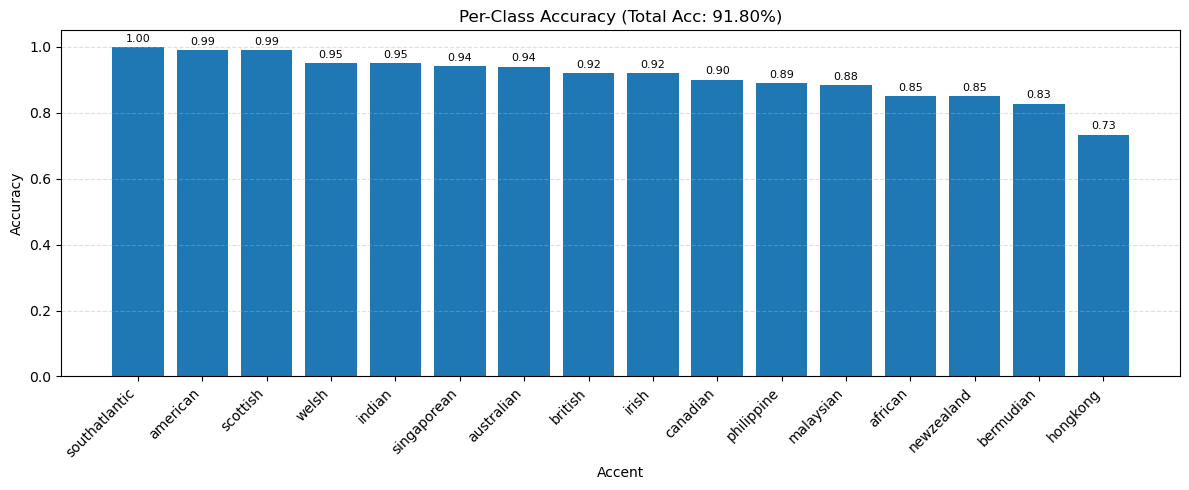

In [6]:
# Sort by per-class accuracy
acc_items = sorted(
    accuracy_dict.items(),
    key=lambda x: np.mean(x[1]),
    reverse=True,   # highest accuracy on the left
)

acc_labels = [item[0].replace("_", " ") for item in acc_items]
acc_values = [np.mean(item[1]) for item in acc_items]

x = np.arange(len(acc_labels))

plt.figure(figsize=(12, 5))
bars = plt.bar(x, acc_values)

plt.xticks(x, acc_labels, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.xlabel("Accent")
plt.title("Per-Class Accuracy (Total Acc: {:.2f}%)".format(total_acc * 100))
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add accuracy labels
for bar, acc in zip(bars, acc_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        acc + 0.01,
        f"{acc:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()